In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_test_scaled)[:,1]

In [10]:
thresholds = [0.3, 0.5, 0.7, 0.8, 0.9, 0.95]

rows = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    rows.append({
        "threshold": t,
        "precision" : precision_score(y_test, y_pred_t, zero_division=0),
        "recall" : recall_score(y_test, y_pred_t, zero_division=0),
        "f1" : f1_score(y_test, y_pred_t, zero_division=0),
        "false_positives" : confusion_matrix(y_test, y_pred_t)[0,1],
        "false_negatives" : confusion_matrix(y_test, y_pred_t)[1,0],
        "true_positives" : confusion_matrix(y_test, y_pred_t)[1,1]
    })

threshold_results = pd.DataFrame(rows)
threshold_results

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives
0,0.30,0.027347,0.918367,0.053113,3201,8,90
1,0.50,0.060976,0.918367,0.114358,1386,8,90
2,0.70,0.121253,0.908163,0.213942,645,9,89
3,0.80,0.159633,0.887755,0.270607,458,11,87
4,0.90,0.247159,0.887755,0.386667,265,11,87
5,0.95,0.390135,0.887755,0.542056,136,11,87


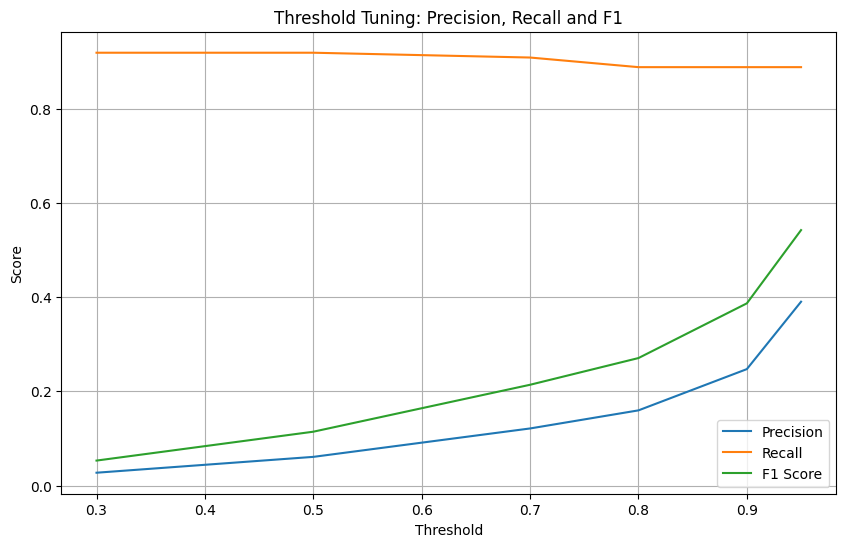

In [11]:
plt.figure(figsize=(10,6))
plt.plot(threshold_results["threshold"], threshold_results["precision"], label = "Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label = "Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label = "F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning: Precision, Recall and F1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
chosen_threshold = 0.9
y_pred_custom = (y_prob >= chosen_threshold).astype(int)

print("Chosen Threshold:", chosen_threshold)
print(classification_report(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

Chosen Threshold: 0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.25      0.89      0.39        98

    accuracy                           1.00     56962
   macro avg       0.62      0.94      0.69     56962
weighted avg       1.00      1.00      1.00     56962

[[56599   265]
 [   11    87]]


In [14]:
risk_score = np.round(y_prob * 100).astype(int)

def score_to_band(score: int) -> str:
    if score < 20:
        return "Low"
    elif score <= 70:
        return "Medium"
    return "High"

risk_band = [score_to_band(score) for score in risk_score]

results = X_test.copy()
results["ActualClass"] = y_test.values
results["FraudProbability"] = y_prob
results["RiskScore"] = risk_score
results["RiskBand"] = risk_band
results["PredictedClass_Custom"] = y_pred_custom

results.sort_values("RiskScore", ascending=False).head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,ActualClass,FraudProbability,RiskScore,RiskBand,PredictedClass_Custom
13942,24735.0,-14.575410,9.802337,-18.043109,6.136942,-11.623105,-3.978362,-13.350186,9.829463,-2.893536,...,0.886971,-0.276769,1.723108,0.547535,89.99,0,1.000000,100,High,1
6717,8408.0,-1.813280,4.917851,-5.926130,5.701500,1.204393,-3.035138,-1.713402,0.561257,-3.796354,...,1.106766,0.323885,0.894767,0.569519,1.00,1,1.000000,100,High,1
214662,139767.0,0.467992,1.100118,-5.607145,2.204714,-0.578539,-0.174200,-3.454201,1.102823,-1.065016,...,0.319869,0.170636,0.851798,0.372098,120.54,1,1.000000,100,High,1
271571,164637.0,1.919683,2.538925,-4.751178,4.666124,2.890538,-1.753877,1.304330,-0.345229,-2.194451,...,0.400890,0.146848,0.012909,0.102838,0.77,0,0.999869,100,High,1
267760,162916.0,-0.400517,3.514639,-2.902389,3.550913,3.568916,-1.575009,2.282890,-0.257712,-3.110190,...,0.290754,0.103289,0.159134,0.308162,0.77,0,0.999875,100,High,1
150663,93853.0,-5.839192,7.151532,-12.816760,7.031115,-9.651272,-2.938427,-11.543207,4.843627,-3.494276,...,-0.275998,0.282435,0.104886,0.254417,316.06,1,1.000000,100,High,1
42009,40919.0,-2.740483,3.658095,-4.110636,5.340242,-2.666775,-0.092782,-4.388699,-0.280133,-2.821895,...,-0.403956,0.277895,0.830062,0.218690,112.33,1,1.000000,100,High,1
216376,140449.0,-2.055063,0.331810,-3.360002,1.077678,5.151589,-1.441581,0.744048,-0.103401,-0.927332,...,-0.056573,-0.250994,-0.039198,0.677591,1.00,0,0.997026,100,High,1
42756,41233.0,-10.645800,5.918307,-11.671043,8.807369,-7.975501,-3.586806,-13.616797,6.428169,-7.368451,...,-0.027898,0.354254,0.273329,-0.152908,0.00,1,1.000000,100,High,1
218442,141320.0,-6.352337,-2.370335,-4.875397,2.335045,-0.809555,-0.413647,-4.082308,2.239089,-1.986360,...,-0.240053,0.112972,0.910591,-0.650944,195.66,1,1.000000,100,High,1
